# RECOVAR × SeisBench demo

Run the RECOVAR ensemble autoencoder as a sliding-window earthquake **detector**
through the standard SeisBench `annotate` / `classify` API.

RECOVAR is a classifier that outputs one earthquake-probability
score in `[0, 1]` per 30 s, 3-component window. `RecovarDetector` is a SeisBench `output_type="point` model that tiles the 30 s window across a
continuous record at a configurable **stride** parameter and stitches the per-window scores into a detection curve. `classify` thresholds that curve into discrete detections.

In this demo, we scan the whole MSEED record continuously using SeisBench `RecovarDetector` 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import obspy
import seisbench.models as sbm

from recovar_torch.seisbench_model import RecovarDetector

MSEED_PATH = "data/test.mseed"
WEIGHTS    = "models/recovar_instance.pt"
THRESHOLD  = 0.5

## Build the detector and load RECOVAR model weights

`models/recovar_instance.pt` is a RECOVAR model trained on instance (`state_dict`).

In [2]:
model = RecovarDetector().eval()
model.load_representation_state_dict(WEIGHTS, map_location="cpu")

print("output_type :", model.output_type)
print("in_samples  :", model.in_samples, "( 30 s @ 100 Hz )")
print("components  :", model.component_order)
print("default stride:", model.default_args["stride"], "samples (=", model.default_args["stride"] / 100, "s )")

output_type : point
in_samples  : 3000 ( 30 s @ 100 Hz )
components  : ZNE
default stride: 100 samples (= 1.0 s )


## Read the continuous stream

RECOVAR expects 100 Hz, 3-component Z/N/E. SeisBench handles component ordering,
resampling, and the 1-20 Hz bandpass during `annotate`.

3 Trace(s) in Stream:
KO.DKL..HHE | 2025-08-10T16:53:04.960000Z - 2025-08-10T17:00:34.950000Z | 100.0 Hz, 45000 samples
KO.DKL..HHN | 2025-08-10T16:53:04.960000Z - 2025-08-10T17:00:34.950000Z | 100.0 Hz, 45000 samples
KO.DKL..HHZ | 2025-08-10T16:53:04.960000Z - 2025-08-10T17:00:34.950000Z | 100.0 Hz, 45000 samples


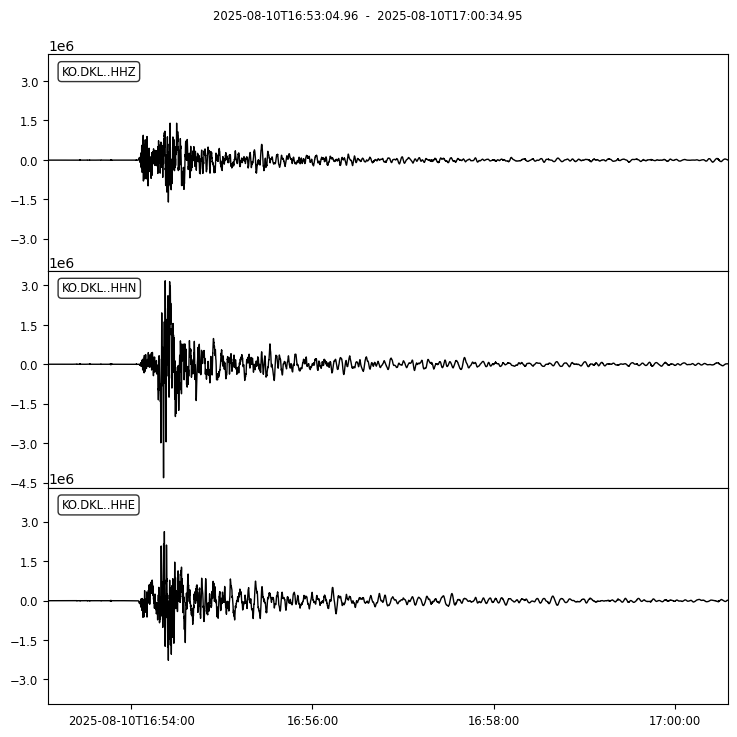

In [3]:
st = obspy.read(MSEED_PATH)
st.merge(method=1, fill_value=0)
print(st)
st.plot();

## Part 1: Continuous scoring (sliding window)

`annotate` tiles the 30 s window across the record and returns a detection curve
as an ObsPy trace, sampled at `sampling_rate / stride`. 

With `stride=100` (1 s) the curve is sampled at 1 Hz.

In [4]:
annotations = model.annotate(st, stride=100)
curve = annotations[0]
print(curve)
print(f"curve sampling rate: {curve.stats.sampling_rate} Hz   ({curve.stats.npts} points)")
print(f"score range: {curve.data.min():.3f} - {curve.data.max():.3f}")

KO.DKL..RecovarDetector_earthquake | 2025-08-10T16:53:19.960000Z - 2025-08-10T17:00:19.960000Z | 1.0 Hz, 421 samples
curve sampling rate: 1.0 Hz   (421 points)
score range: 0.004 - 0.982


## Stride controls window step

The window step is the `stride` argument, in samples at 100 Hz. 

Smaller stride =>more windows => proportionally more compute, but a finer detection curve.

SeisBench batches the windows

In [5]:
for stride in (500, 100, 50, 10):
    a = model.annotate(st, stride=stride)
    print(f"stride={stride:4d} samples ({stride/100:>4.2f} s)  ->  "
          f"curve fs = {a[0].stats.sampling_rate:5.2f} Hz, {a[0].stats.npts:4d} points")

stride= 500 samples (5.00 s)  ->  curve fs =  0.20 Hz,   85 points


stride= 100 samples (1.00 s)  ->  curve fs =  1.00 Hz,  421 points


stride=  50 samples (0.50 s)  ->  curve fs =  2.00 Hz,  841 points


stride=  10 samples (0.10 s)  ->  curve fs = 10.00 Hz, 4201 points


## Part 2: Detections via `classify`

`classify` runs `annotate` and then thresholds the curve into discrete detections using SeisBench's trigger-onset machinery.

In [6]:
out = model.classify(st, stride=100, earthquake_threshold=THRESHOLD)
print(f"{len(out.detections)} detection(s) at threshold {THRESHOLD}:")
for d in out.detections:
    t_rel = d.start_time - st[0].stats.starttime
    print(f"  {d.start_time}  (t+{t_rel:.1f} s)  ->  {d.end_time}   peak score = {d.peak_value:.3f}")

1 detection(s) at threshold 0.5:
  2025-08-10T16:53:50.960000Z  (t+46.0 s)  ->  2025-08-10T16:54:17.960000Z   peak score = 0.982


## Baselines: PhaseNet and EQTransformer

For comparison, we run EQTransformer and PhaseNet via SeisBench as pickers (pretrained `instance` weights)
on the same stream.

In [7]:
phasenet = sbm.PhaseNet.from_pretrained("instance").eval()
eqt = sbm.EQTransformer.from_pretrained("instance").eval()

pn_ann = phasenet.annotate(st)
eqt_ann = eqt.annotate(st)
print("PhaseNet     :", [tr.stats.channel for tr in pn_ann])
print("EQTransformer:", [tr.stats.channel for tr in eqt_ann])

PhaseNet     : ['PhaseNet_P', 'PhaseNet_S', 'PhaseNet_N']
EQTransformer: ['EQTransformer_Detection', 'EQTransformer_P', 'EQTransformer_S']


## Plot the detection curves over the waveform

RECOVAR's earthquake-probability curve on top, with the PhaseNet and EQTransformer
curves stacked below for comparison.

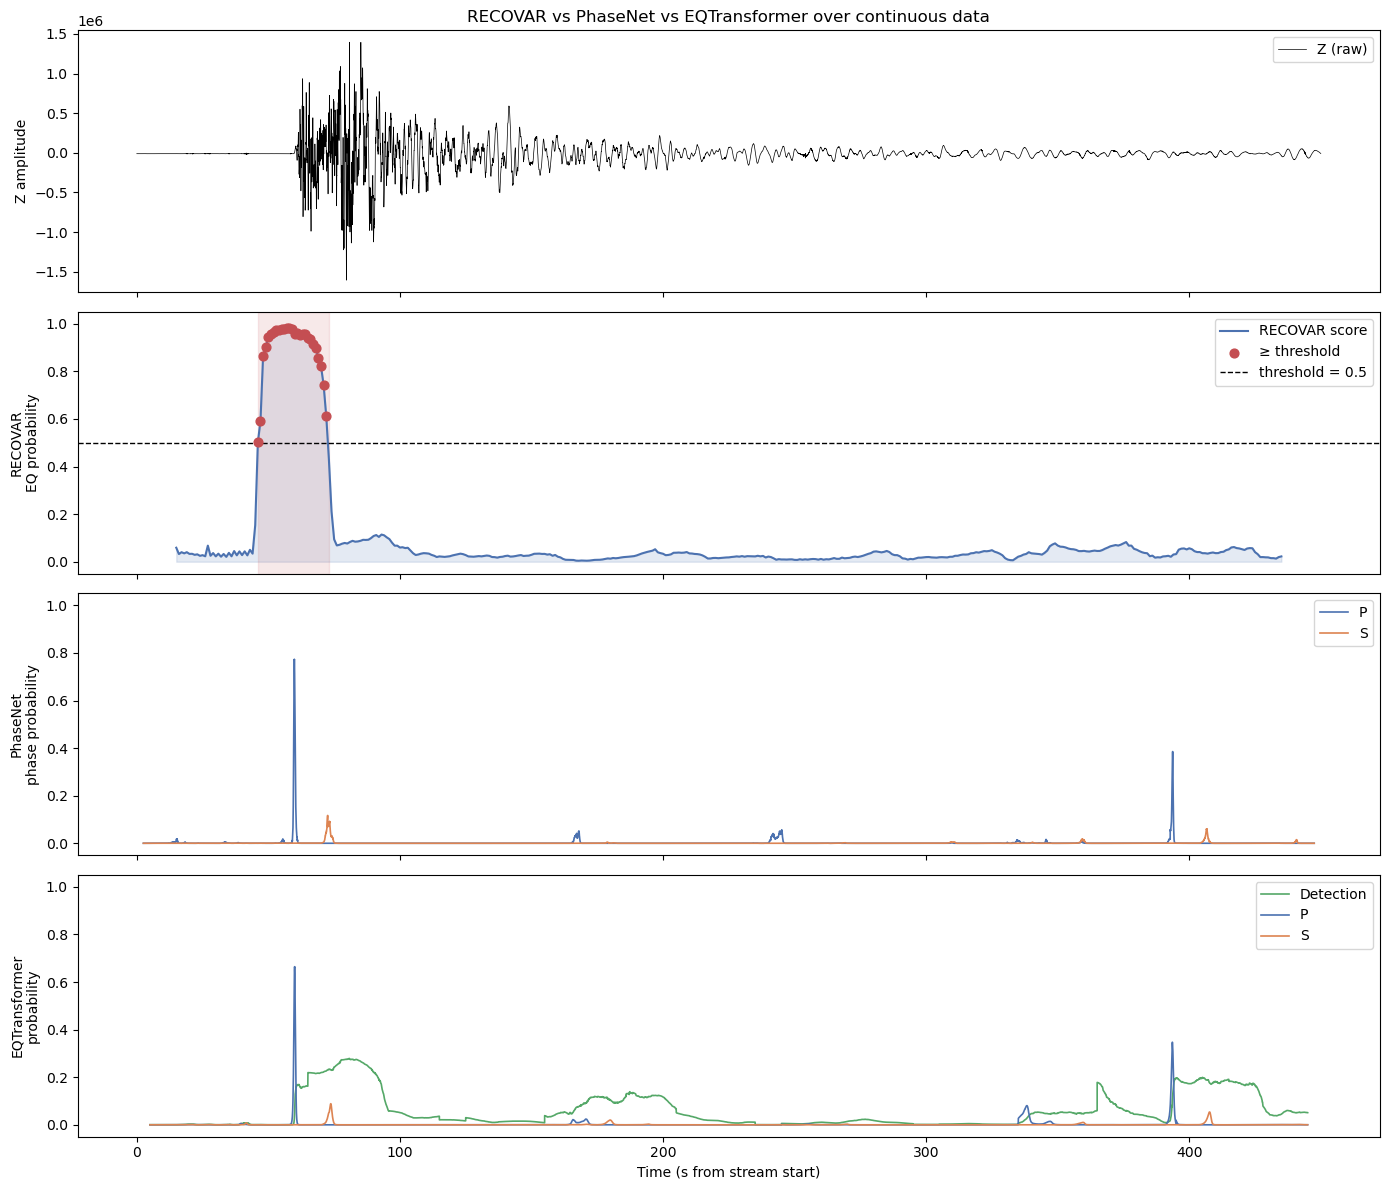

In [8]:
def _curve(ann, channel):
    tr = ann.select(channel=channel)[0]
    t = (tr.stats.starttime - t0) + np.arange(tr.stats.npts) / tr.stats.sampling_rate
    return t, tr.data

t0 = st[0].stats.starttime
z = st.select(channel="*Z")[0]
wave_t = np.arange(z.stats.npts) / z.stats.sampling_rate
curve_t = (curve.stats.starttime - t0) + np.arange(curve.stats.npts) / curve.stats.sampling_rate
above = curve.data >= THRESHOLD

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
ax_w, ax_r, ax_pn, ax_eqt = axes

ax_w.plot(wave_t, z.data, color="black", linewidth=0.5, label="Z (raw)")
ax_w.set_ylabel("Z amplitude")
ax_w.set_title("RECOVAR vs PhaseNet vs EQTransformer over continuous data")
ax_w.legend(loc="upper right")

ax_r.fill_between(curve_t, curve.data, 0, color="#4C72B0", alpha=0.15)
ax_r.plot(curve_t, curve.data, "-", color="#4C72B0", linewidth=1.5, label="RECOVAR score")
ax_r.scatter(curve_t[above], curve.data[above], s=40, color="#C44E52", zorder=3, label="≥ threshold")
ax_r.axhline(THRESHOLD, color="k", linestyle="--", linewidth=1, label=f"threshold = {THRESHOLD}")
for d in out.detections:
    ax_r.axvspan(d.start_time - t0, d.end_time - t0, color="#C44E52", alpha=0.12)
ax_r.set_ylim(-0.05, 1.05)
ax_r.set_ylabel("RECOVAR\nEQ probability")
ax_r.legend(loc="upper right")

for ch, color, label in [("PhaseNet_P", "#4C72B0", "P"), ("PhaseNet_S", "#DD8452", "S")]:
    t, d = _curve(pn_ann, ch)
    ax_pn.plot(t, d, color=color, linewidth=1.2, label=label)
ax_pn.set_ylim(-0.05, 1.05)
ax_pn.set_ylabel("PhaseNet\nphase probability")
ax_pn.legend(loc="upper right")

for ch, color, label in [("EQTransformer_Detection", "#55A868", "Detection"),
                         ("EQTransformer_P", "#4C72B0", "P"),
                         ("EQTransformer_S", "#DD8452", "S")]:
    t, d = _curve(eqt_ann, ch)
    ax_eqt.plot(t, d, color=color, linewidth=1.2, label=label)
ax_eqt.set_ylim(-0.05, 1.05)
ax_eqt.set_ylabel("EQTransformer\nprobability")
ax_eqt.set_xlabel("Time (s from stream start)")
ax_eqt.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Part 3: Labeled benchmark (ROC / AUC)

Score the labeled 30 s test windows through the model's forward path
(the same computation `annotate` runs per window) and look at the ROC curve + AUC score 

test windows: (1280, 3000, 3), positives: 81.6%


AUC = 0.986


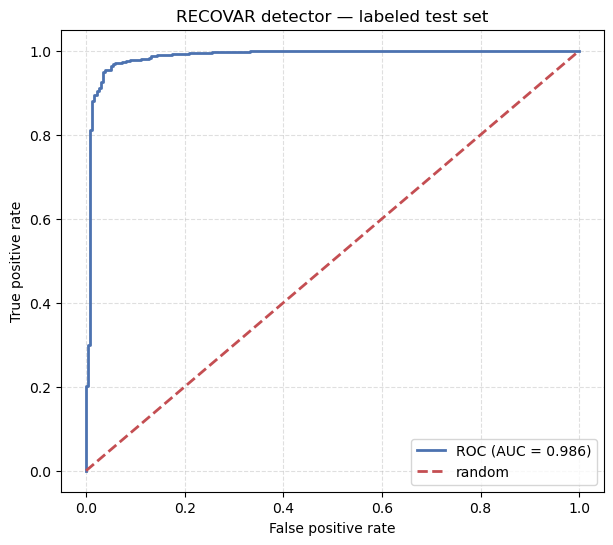

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import torch

X_test = np.load("data/X_test_1280sample.npy")
Y_test = np.load("data/Y_test_1280sample.npy")
print(f"test windows: {X_test.shape}, positives: {Y_test.mean():.1%}")

scores = []
with torch.no_grad():
    for i in range(0, len(X_test), 256):
        xb = torch.tensor(X_test[i:i + 256].transpose(0, 2, 1), dtype=torch.float32)
        pre = model.annotate_batch_pre(xb, argdict={})
        scores.append(model(pre).squeeze(-1).cpu().numpy())
scores = np.concatenate(scores)

fpr, tpr, _ = roc_curve(Y_test, scores)
auc = roc_auc_score(Y_test, scores)
print(f"AUC = {auc:.3f}")

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="#C44E52", lw=2, linestyle="--", label="random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("RECOVAR detector — labeled test set")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()